# Flooding exposure

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

WorldPop [source](https://hub.worldpop.org/geodata/summary?id=35719)

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

from src.datasources import worldpop, codab, floodscan
from src.constants import *

In [3]:
# worldpop.aggregate_worldpop_to_adm2()

In [4]:
# floodscan.clip_tcd_from_glb()

In [5]:
# floodscan.calculate_exposure_raster()

In [6]:
# floodscan.calculate_adm2_exposures()

In [7]:
adm2 = codab.load_codab()
adm2_aoi = adm2[adm2["ADM1_PCODE"].isin(ADM1_FLOOD_EXTRA_PCODES)]
adm1 = adm2.dissolve(by="ADM1_PCODE").reset_index()
adm1_aoi = adm1[adm1["ADM1_PCODE"].isin(ADM1_FLOOD_EXTRA_PCODES)]

In [8]:
adm2

,ADM2_FR,ADM2_PCODE,ADM2_REF,ADM2ALT1FR,ADM2ALT2FR,ADM1_FR,ADM1_PCODE,ADM0_FR,ADM0_PCODE,DATE,VALIDON,VALIDTO,geometry
0,Batha Ouest,TD0101,Batha Ouest,None,None,Batha,TD01,Tchad,TD,2016-07-01,2021-09-24,None,"POLYGON ((19.39467 16.07575, 19.49447 15.90011..."
1,Batha Est,TD0102,Batha Est,None,None,Batha,TD01,Tchad,TD,2016-07-01,2021-09-24,None,"POLYGON ((20.04400 15.66100, 20.05689 14.52958..."
2,Fitri,TD0103,Fitri,None,None,Batha,TD01,Tchad,TD,2016-07-01,2021-09-24,None,"POLYGON ((17.61200 13.45600, 17.75700 13.48100..."
3,Borkou,TD0201,Borkou,None,None,Borkou,TD02,Tchad,TD,2016-07-01,2021-09-24,None,"POLYGON ((20.46087 16.99217, 20.46086 16.99212..."
4,Borkou Yala,TD0202,Borkou Yala,None,None,Borkou,TD02,Tchad,TD,2016-07-01,2021-09-24,None,"POLYGON ((19.18366 18.64927, 19.19120 18.64881..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,Djourf Al Ahmar,TD2102,Djourf Al Ahmar,None,None,Sila,TD21,Tchad,TD,2016-07-01,2021-09-24,None,"POLYGON ((20.44697 13.03353, 20.46987 13.02686..."
66,Tibesti Est,TD2201,Tibesti Est,None,None,Tibesti,TD22,Tchad,TD,2016-07-01,2021-09-24,None,"POLYGON ((19.18635 21.87039, 20.98003 20.98713..."
67,Tibesti Ouest,TD2202,Tibesti Ouest,None,None,Tibesti,TD22,Tchad,TD,2016-07-01,2021-09-24,None,"POLYGON ((16.90852 22.17698, 16.90852 21.83765..."
68,Fada,TD2301,Fada,None,None,Ennedi Ouest,TD23,Tchad,TD,2016-07-01,2021-09-24,None,"POLYGON ((22.34093 20.31697, 22.34157 20.31666..."


In [9]:
pop = worldpop.load_raw_worldpop()
pop_aoi = pop.rio.clip(adm2_aoi.geometry, all_touched=True)
pop_aoi = pop_aoi.where(pop_aoi > 0)

In [10]:
fs_raster = floodscan.load_raw_tcd_floodscan()
fs_raster = fs_raster.rio.write_crs(4326)
fs_aoi = fs_raster.rio.clip(adm2_aoi.geometry, all_touched=True)

fs_aoi_year = fs_aoi.groupby("time.year").max()
fs_aoi_mean = fs_aoi_year.mean(dim="year")

fs_year = fs_raster.groupby("time.year").max()
fs_mean = fs_year.mean(dim="year")

In [11]:
adm2_pop = worldpop.load_adm2_worldpop()

In [14]:
exposure = floodscan.load_adm2_flood_exposures()
exposure = exposure.merge(adm2_pop, on="ADM2_PCODE")
exposure["frac_exposed"] = exposure["total_exposed"] / exposure["total_pop"]

In [15]:
exposure

,year,total_exposed,ADM2_PCODE,total_pop,frac_exposed
0,1998,9972,TD0101,276899.40,0.036013
1,1999,7430,TD0101,276899.40,0.026833
2,2000,1539,TD0101,276899.40,0.005558
3,2001,5367,TD0101,276899.40,0.019382
4,2002,7226,TD0101,276899.40,0.026096
...,...,...,...,...,...
1815,2019,153,TD2303,51791.11,0.002954
1816,2020,287,TD2303,51791.11,0.005541
1817,2021,0,TD2303,51791.11,0.000000
1818,2022,0,TD2303,51791.11,0.000000


<Axes: xlabel='year'>

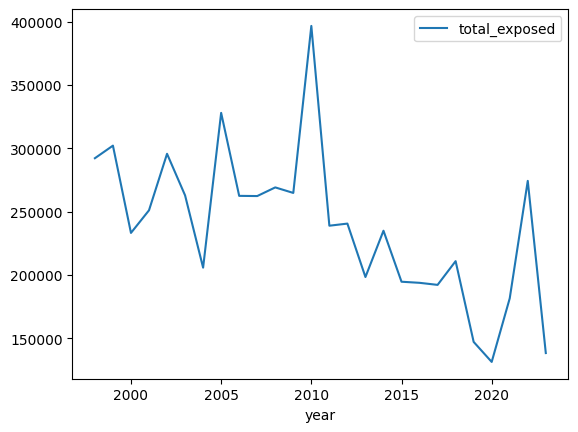

In [19]:
exposure[exposure["ADM2_PCODE"] == NDJAMENA2].plot(x="year", y="total_exposed")

In [161]:
avg_exposure = (
    exposure.groupby("ADM2_PCODE").mean().reset_index().drop(columns=["year"])
)
int_cols = ["total_exposed", "total_pop"]
avg_exposure[int_cols] = avg_exposure[int_cols].astype(int)
avg_exposure_plot = adm2.merge(avg_exposure, on="ADM2_PCODE")
avg_exposure_plot_aoi = avg_exposure_plot[
    avg_exposure_plot["ADM1_PCODE"].isin(ADM1_FLOOD_EXTRA_PCODES)
]

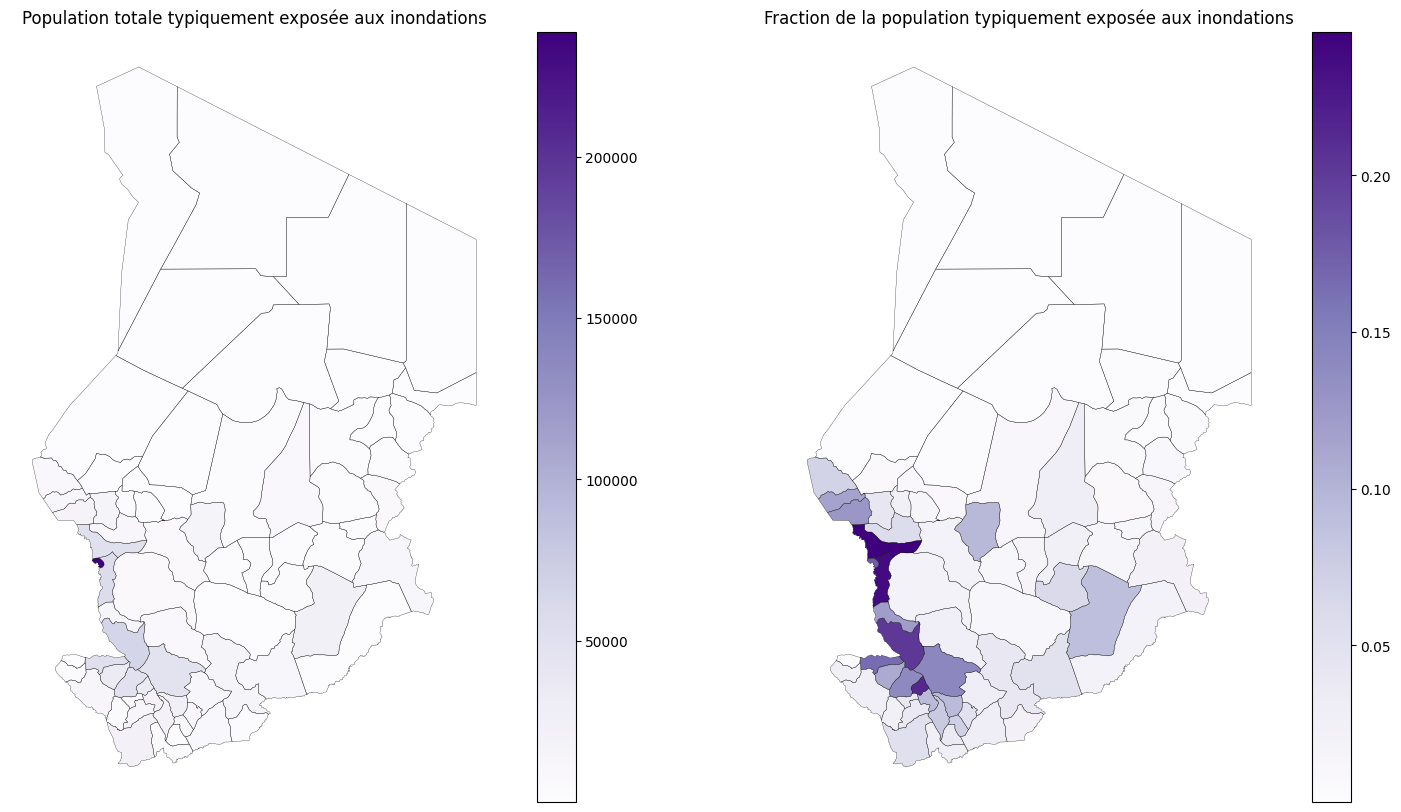

In [162]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(20, 10))

for j, variable in enumerate(["total_exposed", "frac_exposed"]):
    avg_exposure_plot.plot(
        column=variable, ax=axs[j], legend=True, cmap="Purples"
    )
    # for index, row in (
    #     avg_exposure_plot_aoi.sort_values(variable).iloc[-10:].iterrows()
    # ):
    #     centroid = row["geometry"].centroid

    #     axs[j].annotate(
    #         row["ADM2_EN"],
    #         xy=(centroid.x, centroid.y),
    #         xytext=(0, 0),
    #         textcoords="offset points",
    #         ha="center",
    #         va="center",
    #     )

    adm2.boundary.plot(ax=axs[j], linewidth=0.2, color="k")
    axs[j].axis("off")


axs[0].set_title("Population totale typiquement exposée aux inondations")
axs[1].set_title(
    "Fraction de la population typiquement exposée aux inondations"
)

plt.subplots_adjust(wspace=0)

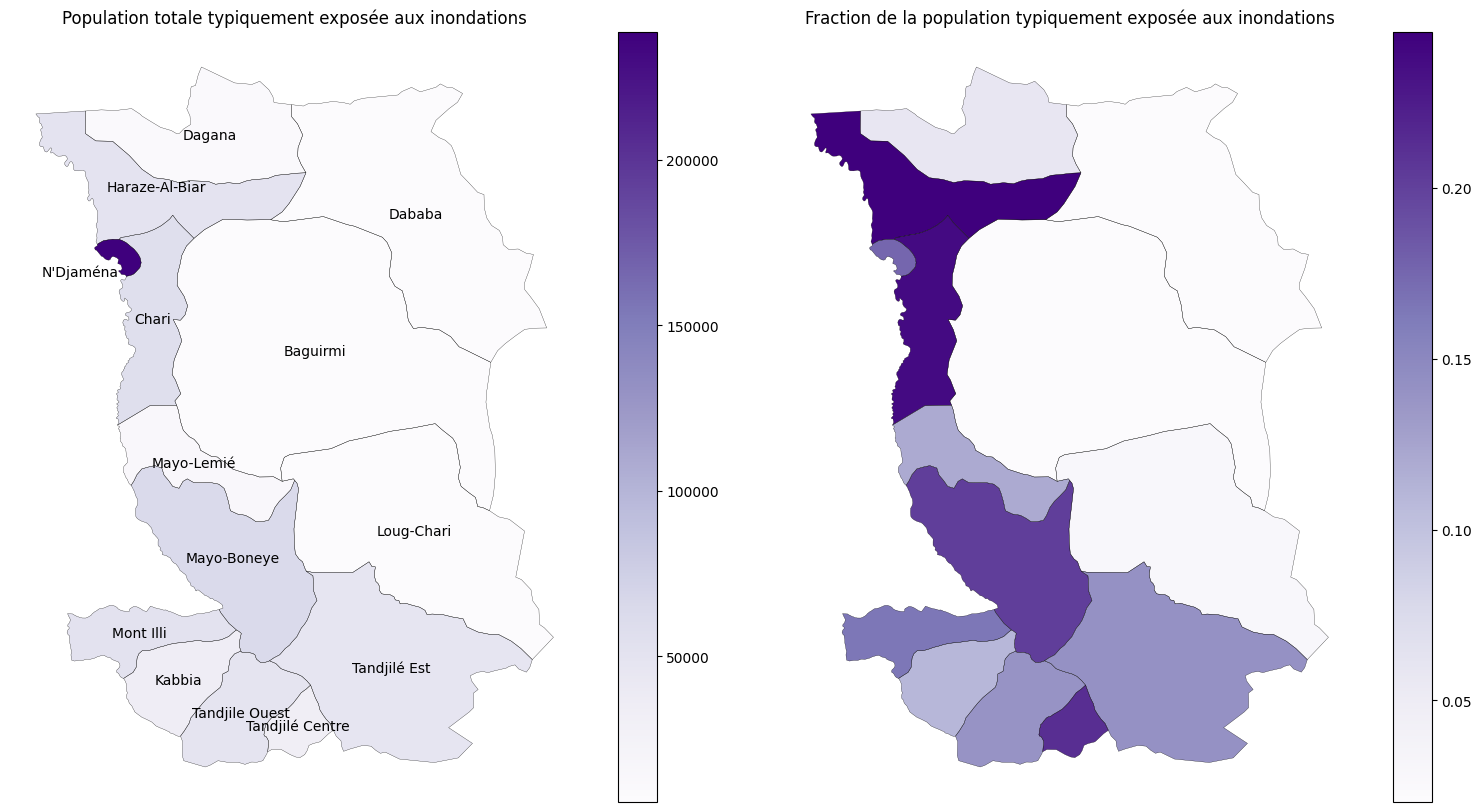

In [170]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(20, 10))

for j, variable in enumerate(["total_exposed", "frac_exposed"]):
    avg_exposure_plot_aoi.plot(
        column=variable, ax=axs[j], legend=True, cmap="Purples"
    )

    adm2_aoi.boundary.plot(ax=axs[j], linewidth=0.2, color="k")
    axs[j].axis("off")


axs[0].set_title("Population totale typiquement exposée aux inondations")
axs[1].set_title(
    "Fraction de la population typiquement exposée aux inondations"
)

for idx, row in adm2_aoi.iterrows():
    # Calculate the centroid of each geometry
    centroid = row.geometry.centroid
    x_shift, y_shift = (
        (-0.25, -0.1) if row["ADM2_FR"] == "N'Djaména" else (0, 0)
    )
    axs[0].annotate(
        row["ADM2_FR"],
        xy=(centroid.x + x_shift, centroid.y + y_shift),
        ha="center",
        va="center",
        fontsize=10,
    )

plt.subplots_adjust(wspace=0)

In [164]:
cols = [
    # "ADM1_PCODE",
    "ADM1_FR",
    # "ADM2_PCODE",
    "ADM2_FR",
    # "total_pop",
    "total_exposed",
    "frac_exposed",
    # "geometry",
]
tot_label = "Pop. totale exposée"
frac_label = "Frac. de pop. exposée"
avg_exposure_plot[cols].sort_values("total_exposed", ascending=False).iloc[
    :10
].rename(
    columns={
        "total_exposed": tot_label,
        "frac_exposed": frac_label,
        "ADM1_FR": "Région",
        "ADM2_FR": "Département",
    }
).style.background_gradient(
    cmap="Purples"
).format(
    "{:,.0f}", subset=[tot_label]
).format(
    "{:.2f}", subset=[frac_label]
)

,Région,Département,Pop. totale exposée,Frac. de pop. exposée
58,N'Djamena,N'Djaména,"238,635",0.18
35,Mayo-Kebbi Est,Mayo-Boneye,"64,874",0.20
6,Chari-Baguirmi,Chari,"57,551",0.24
38,Mayo-Kebbi Est,Mont Illi,"52,039",0.17
14,Hadjer-Lamis,Haraze-Al-Biar,"50,599",0.25
52,Tandjilé,Tandjile Ouest,"49,125",0.14
51,Tandjilé,Tandjilé Est,"46,975",0.14
36,Mayo-Kebbi Est,Kabbia,"34,364",0.11
53,Tandjilé,Tandjilé Centre,"33,947",0.21
48,Salamat,Bahr-Azoum,"22,835",0.09


In [167]:
cols = [
    # "ADM1_PCODE",
    "ADM1_FR",
    # "ADM2_PCODE",
    "ADM2_FR",
    # "total_pop",
    "total_exposed",
    "frac_exposed",
    # "geometry",
]
tot_label = "Pop. totale exposée"
frac_label = "Frac. de pop. exposée"
avg_exposure_plot_aoi[cols].sort_values("total_exposed", ascending=False).iloc[
    :
].rename(
    columns={
        "total_exposed": tot_label,
        "frac_exposed": frac_label,
        "ADM1_FR": "Région",
        "ADM2_FR": "Département",
    }
).style.background_gradient(
    cmap="Purples"
).format(
    "{:,.0f}", subset=[tot_label]
).format(
    "{:.2f}", subset=[frac_label]
)

,Région,Département,Pop. totale exposée,Frac. de pop. exposée
58,N'Djamena,N'Djaména,"238,635",0.18
35,Mayo-Kebbi Est,Mayo-Boneye,"64,874",0.20
6,Chari-Baguirmi,Chari,"57,551",0.24
38,Mayo-Kebbi Est,Mont Illi,"52,039",0.17
14,Hadjer-Lamis,Haraze-Al-Biar,"50,599",0.25
52,Tandjilé,Tandjile Ouest,"49,125",0.14
51,Tandjilé,Tandjilé Est,"46,975",0.14
36,Mayo-Kebbi Est,Kabbia,"34,364",0.11
53,Tandjilé,Tandjilé Centre,"33,947",0.21
37,Mayo-Kebbi Est,Mayo-Lemié,"13,596",0.12


In [166]:
cols = [
    "ADM1_PCODE",
    "ADM1_FR",
    "ADM2_PCODE",
    "ADM2_FR",
    "total_pop",
    "total_exposed",
    "frac_exposed",
    # "geometry",
]
filename = "tcd_aoi_adm2_average_flood_exposed.csv"
avg_exposure_plot_aoi[cols].sort_values(
    "total_exposed", ascending=False
).to_csv(floodscan.PROC_FS_DIR / filename, index=False)

In [72]:
exposure_raster = floodscan.load_raster_flood_exposures()
exposure_raster_aoi = exposure_raster.rio.clip(
    adm2_aoi.geometry, all_touched=True
)

In [73]:
exposure_raster_aoi_mean = exposure_raster_aoi.mean(dim="year")
exposure_raster_aoi_mean = exposure_raster_aoi_mean.where(
    exposure_raster_aoi_mean > 5
)

exposure_raster_mean = exposure_raster.mean(dim="year")
exposure_raster_mean = exposure_raster_mean.where(exposure_raster_mean > 5)

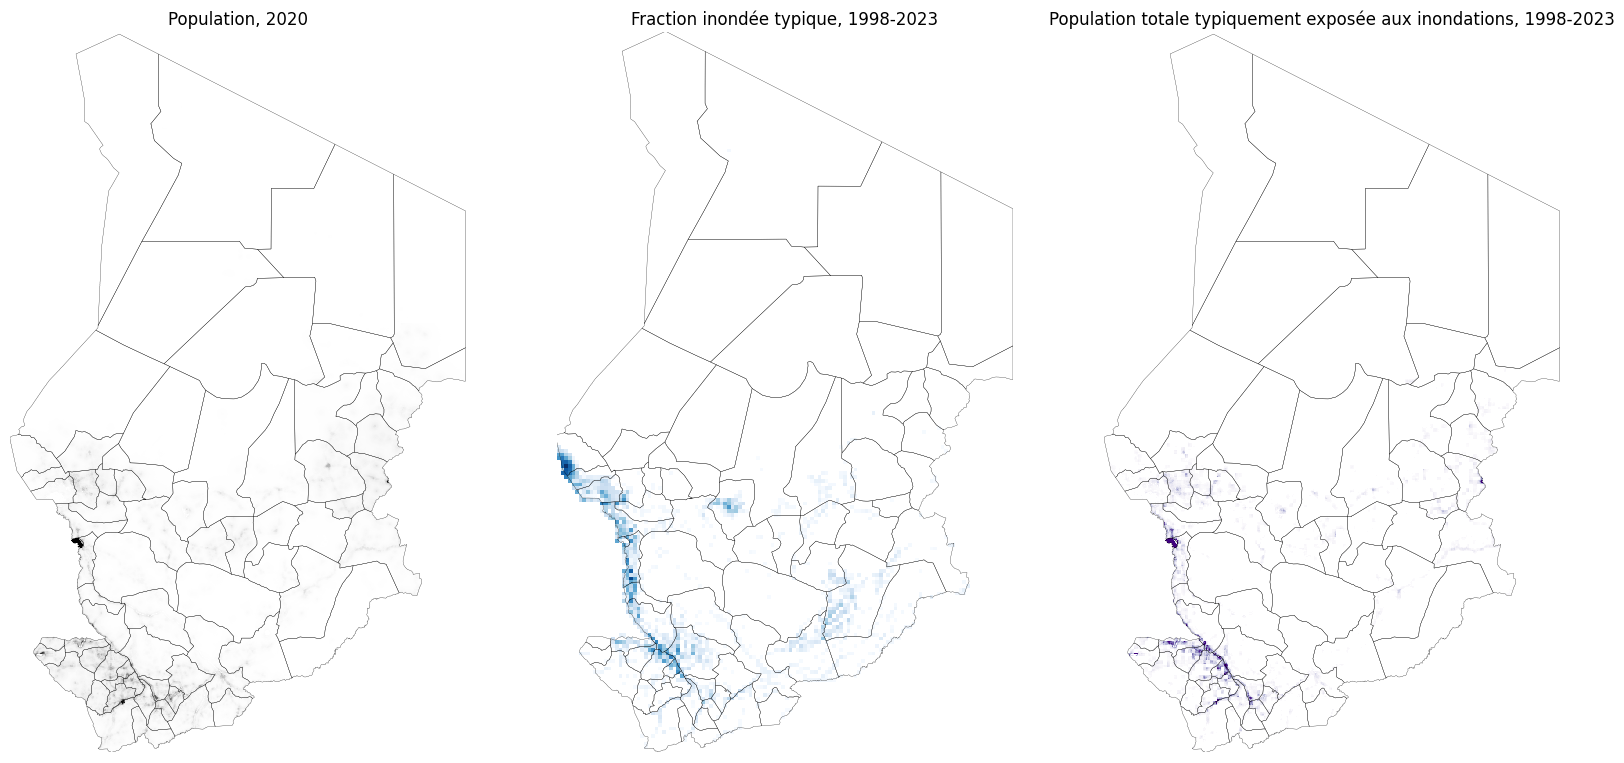

In [86]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(20, 20))

# pop
pop.plot(ax=axs[0], cmap="Greys", vmax=500, add_colorbar=False)
axs[0].set_title("Population, 2020")

# flooding
fs_mean.where(fs_mean > 0.05).plot(ax=axs[1], cmap="Blues", add_colorbar=False)
axs[1].set_title("Fraction inondée typique, 1998-2023")

# exposure
exposure_raster_mean.plot(
    ax=axs[2], cmap="Purples", vmax=80, add_colorbar=False
)
axs[2].set_title(
    "Population totale typiquement exposée aux inondations, 1998-2023"
)

for ax in axs:
    adm2.boundary.plot(ax=ax, linewidth=0.2, color="k")
    ax.axis("off")

plt.subplots_adjust(wspace=0.2)

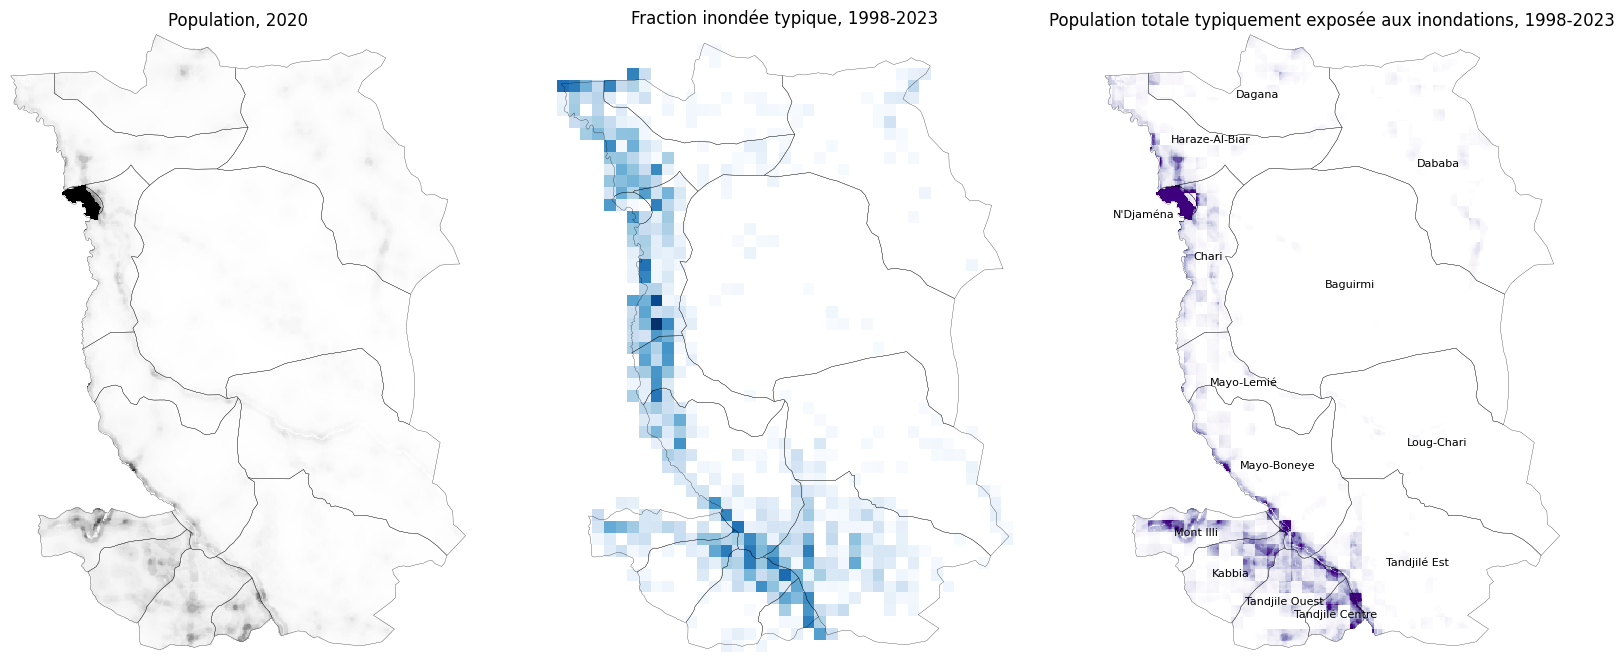

In [137]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(20, 20))

# pop
pop_aoi.plot(ax=axs[0], cmap="Greys", vmax=500, add_colorbar=False)
axs[0].set_title("Population, 2020")

# flooding
fs_aoi_mean.where(fs_aoi_mean > 0.05).plot(
    ax=axs[1], cmap="Blues", add_colorbar=False
)
axs[1].set_title("Fraction inondée typique, 1998-2023")

# exposure
exposure_raster_aoi_mean.plot(
    ax=axs[2], cmap="Purples", vmax=80, add_colorbar=False
)
axs[2].set_title(
    "Population totale typiquement exposée aux inondations, 1998-2023"
)
for idx, row in adm2_aoi.iterrows():
    # Calculate the centroid of each geometry
    centroid = row.geometry.centroid
    x_shift, y_shift = (
        (-0.25, -0.1) if row["ADM2_FR"] == "N'Djaména" else (0, 0)
    )
    axs[2].annotate(
        row["ADM2_FR"],
        xy=(centroid.x + x_shift, centroid.y + y_shift),
        ha="center",
        va="center",
        fontsize=8,
    )

for ax in axs:
    adm2_aoi.boundary.plot(ax=ax, linewidth=0.2, color="k")
    ax.axis("off")

plt.subplots_adjust(wspace=0.2)